### dependencies 

In [25]:
import os
from scipy import stats
import numpy as np 
import pandas as pd
import seaborn as sns
import warnings
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy.stats import wilcoxon, sem
from scipy.stats import gaussian_kde, levene
from scipy.stats import ttest_rel, ttest_ind, mannwhitneyu, shapiro
from itertools import combinations
import matplotlib.cm as cm
import json
import ast

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


#### make sure all file paths in the following code blocks point to the folder you downloaded the data files to

# Figures 1, S1, and S2: Connectomics
## !! run in MATLAB !!

In [1]:
## 1. Update user inputs with appropriate file names and file paths
# userInputs.mat
    # make sure you have downloaded all of the 'data' files:
        # .txt files (6 total)
        # _paths MAT files (6 total)
        # _connections_ MAT files (3 total)
        # _categorizedConnections_ MAT files (4 total)
        # _diagraph_ MAT files (4 total)

## 2. Run Functions ('InitializeDiagraphFunctions')
## A) splitPaths.mat
## B) digraph12n.mat
## C) plotDiagraph.mat
## D) digraph4n.mat
## E) digraph8n.mat
## F) diagraph10n.mat

## 3. Make Network Graphs to combine and use for Figure 1Bi-Bii
# Analyze APN2->AMN using apnAmnNetworkGraph.mat
# Analyze JON->APN2 using jonApnNetworkGraph.mat
# Analyze BN_ant->APN2 using bnApnNetworkGraph.mat
# Analyze independent inhibitory inputs into APN2 using indInhibInputNetworkGraph.mat

## 4. Make pie charts of NT composition of APN2 inputs for Figure 1Ci-Ciii
# Analyze direct inputs to APN2 using excVsInhPiechart.mat
# Analyze JO-dependent inputs into APN2 using excVsInh_apnInputsDownstreamJons_piechart.mat
# Analyze Bristle-dependent inputs into APN2 using excVsInh_apnInputsDownstreamBNs_piechart.mat

## 5. Make bar graph of inhibitory connections for Figure 1D
# using apnInhInputs_JonDepVsInd.mat

## 6. Make network graph for Figure 1E
# using inputsPremApnNetworkGraph.mat

## 7. Make heat maps for Figure 1Ai,Aii
# using sensoryToAPN2HeatMap.mat
# uses already analyzed connections from JONs and BM_ant to APN2, 
    # while also anaylzing DNx01->APN2 and BM_head->APN2

## 8. Make heat map for Figure 1F
# using apn2toAMNheatMap.mat

#### Supplamental S1 and S2 ####
## 9. Make Connectivity network for Figure S1A
# using sensoryInputNetworkGraph.mat

## 10. Make cosine similarity matrix for Figure S1B
# using sensoryInput_cosineSimilarityHeatMap

## 11. Make connectivity network for Figure S2
# apn2PmnNetworkGraph.mat

### all code can be downloaded and run as a single matlab file using APN2_connectomics_code.mat

# FIGURE S3: plots average APN2 membrane potential during quiesence and flight when the antennae are free VS glued
### reports statistical signifigance for global mean ± SEM of Vm for quiescent and flying flies under two conditions: antennae free & JONs blocked, and the mean difference between APN2 Vm during quiescence and flight within antennae free and JONs blocked groups.

In [2]:
# 1. download all .mat files: 
# in MATLAB_figS3 folder:
    # t.mat
    # allCellVm.mat
    # deltaVmAll.mat
    # fileNames.mat
    # groupAvgVm.mat
    # groupSemVm.mat
    # numTrialsPerCell.mat
    # outputFolder.mat
    # steadyVmAll.mat
    # stepCurrents.mat

# 2. load variables before plotting
# ex) load(filepath/allCellVm.mat)

# 3. plot data
#plot Figure S3B average Vm responses with plotAverageAcrossCells.mat
# plot Figure S3C all average per-cell IV curves with plotAllIVCurves.mat
    # and average IV curve with plotAllIVCurves_wLinReg.mat (also reports per-cell average slope & R^2, alongside global R^2)

# FIGURE 2E: plots average APN2 membrane potential during quiesence and flight when the antennae are free VS glued
### reports statistical signifigance for global mean ± SEM of Vm for quiescent and flying flies under two conditions: antennae free & JONs blocked, and the mean difference between APN2 Vm during quiescence and flight within antennae free and JONs blocked groups.

--- antennae free ---
quiescent mean ± SEM: -34.131 ± 1.976
flight mean ± SEM:    -36.362 ± 1.722
Mean diff: -2.232
Paired T-Test: T-stat = -2.4412, p-value = 0.0373, (*)
--- antennae glued ---
quiescent mean ± SEM: -38.087 ± 1.048
flight mean ± SEM:    -39.446 ± 0.932
Mean diff: -1.359
Wilcoxon signed-rank test: W = 6.000, p = 0.014 (*)

--- quiesence ---
Mean diff: -3.957
noGlue vs glue: students t-test: t = 1.817, p = 0.0851 (n.s.)
--- flight ---
Mean diff: -3.084
noGlue vs glue: Mann–Whitney U: U = 74.0, p = 0.1927 (n.s.)


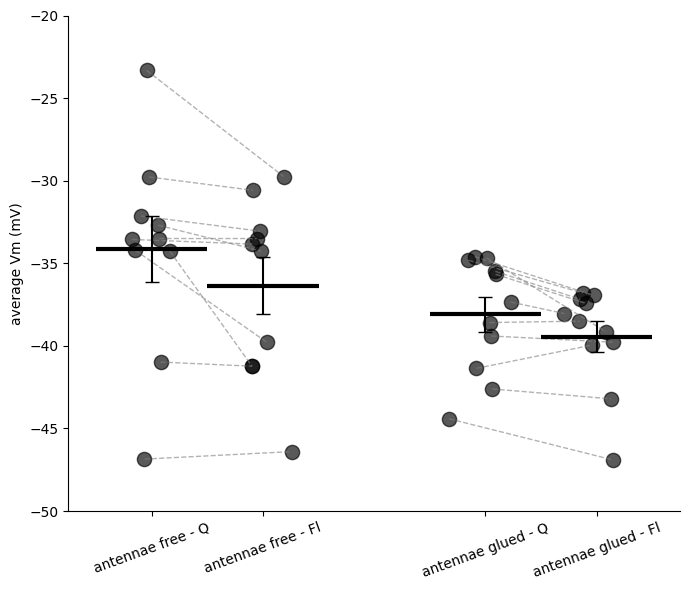

In [26]:
# 1. import csv files: Fig2_noGlueQ_averages, Fig2_noGlueFl_averages, Fig2_glueQ_averages, Fig2_glueFl_averages
def load_averages_from_csv(csv_path):
    df = pd.read_csv(csv_path) # read CSV containing unique identifiers & per-cell average Vm values
    required_cols = ['cell_id', 'avg_vm', 'n_trials']
    if not all(col in df.columns for col in required_cols):
        raise ValueError(f"CSV must contain columns: {required_cols}")
    return list(zip(df['cell_id'], df['avg_vm'], df['n_trials'])) # convert to list of (cell_id, avg_vm, n_trials) tuples
    
# ensure file path is correct before plotting
averages_noGlue_QpairedWfl = load_averages_from_csv('/Users/nunno/Library/CloudStorage/OneDrive-Vanderbilt/revised_APN2publication_data/Fig2_noGlueQ_averages.csv')
averages_noGlue_fl = load_averages_from_csv('/Users/nunno/Library/CloudStorage/OneDrive-Vanderbilt/revised_APN2publication_data/Fig2_noGlueFl_averages.csv')

averages_glue_QpairedWfl = load_averages_from_csv('/Users/nunno/Library/CloudStorage/OneDrive-Vanderbilt/revised_APN2publication_data/Fig2_glueQ_averages.csv')
averages_glue_fl = load_averages_from_csv('/Users/nunno/Library/CloudStorage/OneDrive-Vanderbilt/revised_APN2publication_data/Fig2_glueFl_averages.csv')

#2. plot data:
def plot_combined_connected_Vm(averages_Q_notnorm, averages_fl_notnorm, averages_Q_norm, averages_fl_norm, labels=('Not normal', 'Normal', 'q', 'fl')):
    
    # Extract values from the second column in imported csv file (avg Vm per cell)
    q_notnorm = np.array([avg for _,  avg, _ in averages_Q_notnorm]) 
    fl_notnorm = np.array([avg for _, avg, _ in averages_fl_notnorm])
    q_norm = np.array([avg for _, avg, _ in averages_Q_norm])
    fl_norm = np.array([avg for _, avg, _ in averages_fl_norm])

    # calculate means & SEMs
    mean_q_notnorm, mean_fl_notnorm = np.mean(q_notnorm), np.mean(fl_notnorm)
    sem_q_notnorm, sem_fl_notnorm = sem(q_notnorm), sem(fl_notnorm)

    mean_q_norm, mean_fl_norm = np.mean(q_norm), np.mean(fl_norm)
    sem_q_norm, sem_fl_norm = sem(q_norm), sem(fl_norm)

    # calculate stats
    # Antenna free: Quiesence VS flight (paired ttest)
    free_stat, free_p = stats.ttest_rel(fl_notnorm, q_notnorm)
    # Antennae glued: Quiesence VS flight(Wilcoxon test (paired, non-parametric))
    stat, p = wilcoxon(q_norm, fl_norm)
    # Quiescence: noGlue vs glue (student ttest)
    t_q, p_q = stats.ttest_ind(q_notnorm, q_norm, equal_var=True)
    # Flight: noGlue vs glue (Mann–Whitney U)
    u_fl, p_fl = stats.mannwhitneyu(fl_notnorm, fl_norm, alternative='two-sided')
    
    #define signifigance levels
    def significance_label(p):
        if p < 0.001:
            return "***"
        elif p < 0.01:
            return "**"
        elif p < 0.05:
            return "*"
        else:
            return "n.s."

    # Print stats
    print(f"--- {labels[0]} ---") #antennae free
    print(f"quiescent mean ± SEM: {mean_q_notnorm:.3f} ± {sem_q_notnorm:.3f}")
    print(f"flight mean ± SEM:    {mean_fl_notnorm:.3f} ± {sem_fl_notnorm:.3f}")
    print(f"Mean diff: {mean_fl_notnorm - mean_q_notnorm:.3f}")
    print(f"Paired T-Test: T-stat = {free_stat:.4f}, p-value = {free_p:.4f}, ({significance_label(free_p)})")
    
    print(f"--- {labels[1]} ---") #antennae glued
    print(f"quiescent mean ± SEM: {mean_q_norm:.3f} ± {sem_q_norm:.3f}")
    print(f"flight mean ± SEM:    {mean_fl_norm:.3f} ± {sem_fl_norm:.3f}")
    print(f"Mean diff: {mean_fl_norm - mean_q_norm:.3f}")
    print(f"Wilcoxon signed-rank test: W = {stat:.3f}, p = {p:.3f} ({significance_label(p)})\n")

    print(f"--- {labels[2]} ---") # quiesence free VS glued)
    print(f"Mean diff: {mean_q_norm - mean_q_notnorm:.3f}")
    print(f"noGlue vs glue: students t-test: t = {t_q:.3f}, p = {p_q:.4f} ({significance_label(p_q)})")

    print(f"--- {labels[3]} ---") # flight free VS glued)
    print(f"Mean diff: {mean_fl_norm - mean_fl_notnorm:.3f}")
    print(f"noGlue vs glue: Mann–Whitney U: U = {u_fl:.1f}, p = {p_fl:.4f} ({significance_label(p_fl)})")

    # Plot
    fig, ax = plt.subplots(figsize=(7, 6))
    jitter_strength = 0.015

    # First dataset (antennae free - not normal)
    x_q1, x_fl1 = 0.3, 0.4 #adjusts wehre on the x axis the data is plotted
    jitter_q1 = np.random.normal(0, jitter_strength, size=len(q_notnorm)) #jitter points so all data points are visable
    jitter_fl1 = np.random.normal(0, jitter_strength, size=len(fl_notnorm))
    ax.scatter(x_q1 + jitter_q1, q_notnorm, color='black', s=105, alpha=0.65) #plots data in scatter plot
    ax.scatter(x_fl1 + jitter_fl1, fl_notnorm, color='black', s=105, alpha=0.65)
    for qv, flv, jq, jf in zip(q_notnorm, fl_notnorm, jitter_q1, jitter_fl1):
        ax.plot([x_q1 + jq, x_fl1 + jf], [qv, flv], color='gray', linestyle='--', linewidth=1, alpha=0.6) #connects paired data across flight and quiesence
    ax.hlines(mean_q_notnorm, x_q1-0.05, x_q1+0.05, colors='black', linewidth=3) #plots group average
    ax.errorbar(x_q1, mean_q_notnorm, yerr=sem_q_notnorm, fmt='none', color='black', capsize=5) #plots SEM range with caps
    ax.hlines(mean_fl_notnorm, x_fl1-0.05, x_fl1+0.05, colors='black', linewidth=3) 
    ax.errorbar(x_fl1, mean_fl_notnorm, yerr=sem_fl_notnorm, fmt='none', color='black', capsize=5)

    # Second dataset (antennae glued - normal)
    x_q2, x_fl2 = 0.6, 0.7
    jitter_q2 = np.random.normal(0, jitter_strength, size=len(q_norm))
    jitter_fl2 = np.random.normal(0, jitter_strength, size=len(fl_norm))
    ax.scatter(x_q2 + jitter_q2, q_norm, color='black', s=105, alpha=0.65)
    ax.scatter(x_fl2 + jitter_fl2, fl_norm, color='black', s=105, alpha=0.65)
    for qv, flv, jq, jf in zip(q_norm, fl_norm, jitter_q2, jitter_fl2):
        ax.plot([x_q2 + jq, x_fl2 + jf], [qv, flv], color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.hlines(mean_q_norm, x_q2-0.05, x_q2+0.05, colors='black', linewidth=3)
    ax.errorbar(x_q2, mean_q_norm, yerr=sem_q_norm, fmt='none', color='black', capsize=5)
    ax.hlines(mean_fl_norm, x_fl2-0.05, x_fl2+0.05, colors='black', linewidth=3)
    ax.errorbar(x_fl2, mean_fl_norm, yerr=sem_fl_norm, fmt='none', color='black', capsize=5)

    # X ticks & labels
    ax.set_xticks([x_q1, x_fl1, x_q2, x_fl2])
    ax.set_xticklabels([
        f"{labels[0]} - Q", f"{labels[0]} - Fl",
        f"{labels[1]} - Q", f"{labels[1]} - Fl"
    ], rotation=20)
    ax.set_ylabel("average Vm (mV)")
    ax.set_yticks([-50, -45, -40, -35, -30, -25, -20])

    # layout
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()

    # show
    plt.show()

#Call function:
plot_combined_connected_Vm(
    averages_noGlue_QpairedWfl, averages_noGlue_fl,
    averages_glue_QpairedWfl, averages_glue_fl,
    labels=('antennae free', 'antennae glued', 'quiesence', 'flight'))

# Figure 3B-C: plots response of antennal position and APN2 membrane potential to airflow during quiescence (3B) and flight (3C), both when the antennae are free and when the JONs are blocked

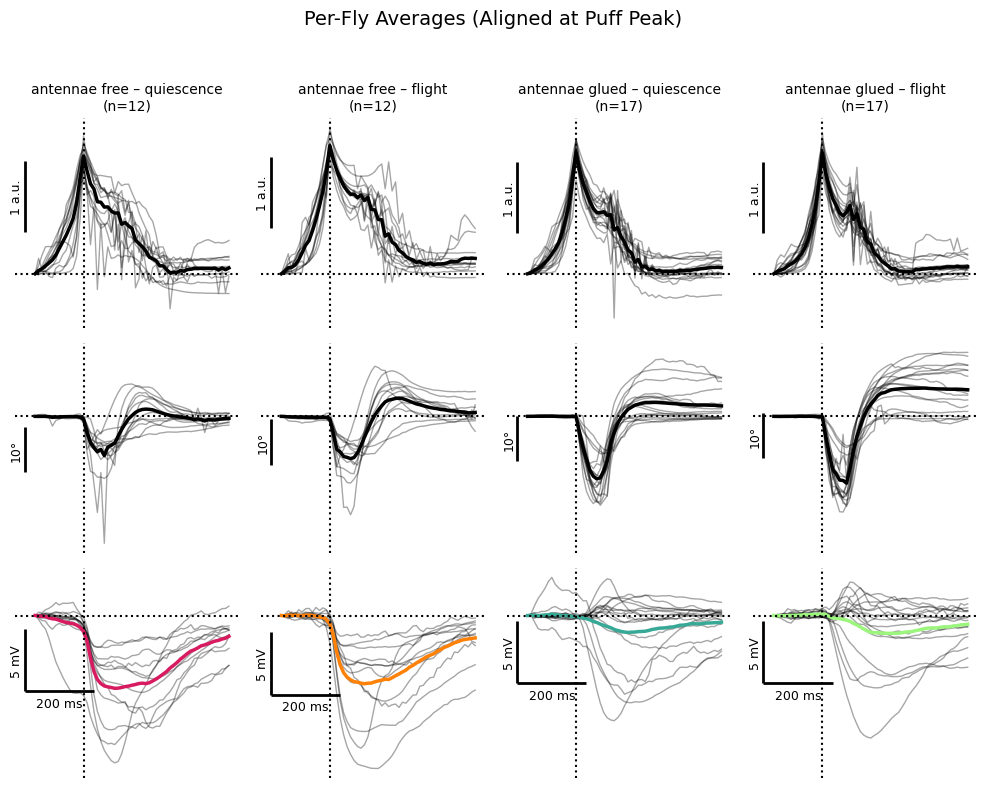

In [97]:
# 1. import csv file: Fig3BC_puffResponseTraces
    #contains per-APN2 cell, per-condition (antennae free VS glued & flight VS quiesence) aligned average traces for air flow, antenna, and Vm data
def load_puffResponse_from_csv(csv_path):
    df = pd.read_csv(csv_path) # read CSV containing unique identifiers & per-cell average Vm values
    for col in ['puff_trace', 'aa_trace', 'vm_norm_trace', 'vm_raw_trace']:
        df[col] = df[col].apply(lambda x: np.array(json.loads(x)))
    return df
    
#ensure file path is correct before plotting:
per_fly_puffResponse = load_puffResponse_from_csv('/Users/nunno/Library/CloudStorage/OneDrive-Vanderbilt/revised_APN2publication_data/Fig3BC_puffResponseTraces.csv')

#2. plot:
def plot_colored_per_fly_averages(per_fly_df, labels, colors, center_at=14,figsize=(10, 8)):
    
    #set time axis based on the actual trace length
    sample_interval_ms = 10
    max_trace_len = len(per_fly_df['puff_trace'].iloc[0]) #57
    t = (np.arange(max_trace_len) - center_at) * sample_interval_ms #centers at puff peak (= data point 15)
    n_conditions = len(labels)

    #set up figure
    fig, axes = plt.subplots(3, n_conditions, figsize=figsize, sharex=True, sharey='row')
    scalebar_units = ['1 a.u.', '10°', '5 mV']
    scalebar_values = [1.0, 10.0, 5.0]
    scalebar_lengths = [200] * 3  # ms
    signal_cols = ['puff_trace', 'aa_trace', 'vm_norm_trace']
    
    #baseline subtract all traces
    for col in signal_cols:
        per_fly_df[col] = per_fly_df[col].apply(lambda x: np.asarray(x) - np.asarray(x)[0])

    for col, label in enumerate(labels):
        cond_df = per_fly_df[per_fly_df['condition'] == label] #loop through every condition
        sample_size = len(cond_df) #rows contained in each condition = sample size

        for row, sig_col in enumerate(signal_cols):
            ax = axes[row, col]

            # Stack per-fly traces for this condition and signal (baseline subtracted)
            traces = np.stack(cond_df[sig_col].values)

            # Plot all per-fly traces in black
            for trace in traces:
                ax.plot(t, trace, color='black', alpha=0.35, linewidth=1)

            # Plot global average in color ONLY for the bottom row (Vm)
            if row == 2:  # bottom row
                color = colors[col]
                ax.plot(t, traces.mean(axis=0), color=color, linewidth=2.5)
            else:
                # Keep average trace in black for top rows
                ax.plot(t, traces.mean(axis=0), color='black', linewidth=2.5)

            # Reference lines (vertical line defines stimulus onset, horizontal line defines baseline)
            ax.axvline(0, linestyle=':', color='black')
            ax.axhline(0, linestyle=':', color='black')

            # Formatting 
            ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
            ax.tick_params(axis='both', left=False, bottom=False,
                           labelleft=False, labelbottom=False)

            # Scale bars
            y0 = ax.get_ylim()[0] + 0.45 * (ax.get_ylim()[1] - ax.get_ylim()[0])
            y1 = y0 + scalebar_values[row]
            x0 = t[0] - 30
            x1 = x0 + scalebar_lengths[row]

            # Vertical scale bars
            ax.vlines(x0, y0, y1, color='black', linewidth=2, clip_on=False)
            ax.text(x0 - 5, (y0 + y1) / 2, scalebar_units[row],
                    ha='right', va='center', fontsize=9, rotation=90)

            # Horizontal scale bar (for bottom row, e.g., Vm)
            if row == 2:
                ax.hlines(y=y0, xmin=x0, xmax=x1, color='black', linewidth=2, clip_on=False)
                text_offset = -1.5  # small offset in data units
                ax.text((x0 + x1) / 2, y0 + text_offset,
                        f'{scalebar_lengths[row]} ms', ha='center', va='bottom', fontsize=9)

            if row == 0:
                ax.set_title(f"{label}\n(n={sample_size})", fontsize=10)

    plt.suptitle('Per-Fly Averages (Aligned at Puff Peak)', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

#Call function:
plot_colored_per_fly_averages(per_fly_puffResponse,
    labels=['antennae free – quiescence','antennae free – flight','antennae glued – quiescence','antennae glued – flight'],
    colors=['#D81B60', '#FF8107', '#38A996', '#9CF67D'])

# FIGURE S5B-C: plots the average (B) peak-to-peak antennal deflection OR (C) final antennal position VS APN2 Vm during quiescence and flight, both when the antennae are free and when the JONs are blocked
## mean ± SEM plotted for each condition 

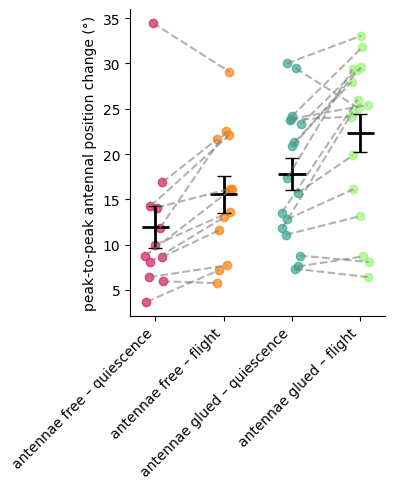

In [28]:
#Figure S5B
# 1. import csv file: Fig3BC_allPeakData.csv
    #contains:'condition','date','expNumber','negative_to_positive_change_deg'
def load_all_peak_data(csv_path):
    df = pd.read_csv(csv_path)
    return df
    
# 2. ensure file path is correct before plotting:
all_peak_data = load_all_peak_data('/Users/nunno/Library/CloudStorage/OneDrive-Vanderbilt/revised_APN2publication_data/Fig3BC_allPeakData.csv')


# 3. plot data for Figure S5B
def plot_aa_negative_to_positive_scatter(
    peak_df,
    labels,
    colors,
    figsize=(4, 5),
    star_offset=1.5
):

    plt.figure(figsize=figsize)
    ax = plt.gca()

    # Map condition labels to x positions
    x_pos = {label: i for i, label in enumerate(labels)}

    # Store jittered x positions for connecting paired data
    jitter_dict = {}

    # Plot individual flies + mean ± SEM
    for i, label in enumerate(labels):
        subset = peak_df.loc[peak_df['condition'] == label,['date', 'expNumber', 'negative_to_positive_change_deg']].dropna(subset=['negative_to_positive_change_deg'])
        values = subset['negative_to_positive_change_deg']

        # Jitter individual flies
        x_jitter = (np.random.uniform(-0.15, 0.15, size=len(subset))+ i)
        ax.scatter(x_jitter,values,color=colors[i],alpha=0.7)

        # Store jitter positions for paired connections
        for date, exp, xj, yval in zip(subset['date'],subset['expNumber'],x_jitter,values):
            jitter_dict.setdefault((date, exp), {})[label] = (xj, yval)

        # Mean ± SEM
        mean_val = np.nanmean(values)
        sem_val = (np.nanstd(values, ddof=1)/ np.sqrt(len(values)))
        ax.hlines(mean_val,i - 0.2,i + 0.2,color='black',linewidth=2)
        ax.errorbar(i,mean_val,yerr=sem_val,fmt='none',ecolor='black',elinewidth=2,capsize=5)

    # Connect paired values
    for (date, exp), cond_dict in jitter_dict.items():
        # Free: quiescence & flight
        if ('antennae free – quiescence' in cond_dict and 'antennae free – flight' in cond_dict):
            x1, y1 = cond_dict['antennae free – quiescence']
            x2, y2 = cond_dict['antennae free – flight']
            ax.plot([x1, x2],[y1, y2],linestyle='--',color='grey',alpha=0.6)

        # Glued: quiescence & flight
        if ('antennae glued – quiescence' in cond_dict and 'antennae glued – flight' in cond_dict):
            x1, y1 = cond_dict['antennae glued – quiescence']
            x2, y2 = cond_dict['antennae glued – flight']

            ax.plot([x1, x2],[y1, y2],linestyle='--',color='grey',alpha=0.6)

    # Formatting
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels,rotation=45,ha='right')
    ax.set_ylabel('peak-to-peak antennal position change (°)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(top=False,right=False)

    plt.tight_layout()
    plt.show()

plot_aa_negative_to_positive_scatter(all_peak_data,
    labels = ['antennae free – quiescence','antennae free – flight','antennae glued – quiescence','antennae glued – flight'],
    colors = ['#D81B60','#FF8107','#38A996','#9CF67D'])

In [98]:
#4. report stats on peak-to-peak change in antenal position (Figure S5B)
def test_aa_negative_to_positive(peak_df,labels):
    value_col = 'negative_to_positive_change_deg'

    # Define comparisons
    paired_comparisons = [('antennae free – quiescence','antennae free – flight'),
        ('antennae glued – quiescence','antennae glued – flight')]
    unpaired_comparisons = [('antennae free – quiescence','antennae glued – quiescence'),
        ('antennae free – flight', 'antennae glued – flight')]
    results = []

    # PAIRED COMPARISONS
    for cond1, cond2 in paired_comparisons:
        df1 = peak_df[peak_df['condition'] == cond1][['date', 'expNumber', value_col]].dropna()
        df2 = peak_df[peak_df['condition'] == cond2][['date', 'expNumber', value_col]].dropna()

        # Match the same fly/experiment
        paired = pd.merge(df1,df2,on=['date', 'expNumber'],suffixes=('_1', '_2'))
        vals1 = paired[f'{value_col}_1'].values
        vals2 = paired[f'{value_col}_2'].values

        # Check sample size
        print('\n' + '=' * 60)
        print(f'PAIRED: {cond1} vs {cond2}')
        print(f'n = {len(paired)} paired flies')

        if len(paired) < 3:
            print('Not enough paired observations for testing.')
            continue

        # Test normality of paired differences
        differences = vals2 - vals1
        shapiro_stat, shapiro_p = shapiro(differences)

        print(f'Shapiro-Wilk normality test on differences: 'f'p = {shapiro_p:.4f}')

        # Choose statistical test
        if shapiro_p > 0.05:
            stat, pval = ttest_rel(vals1,vals2)
            test_name = 'Paired t-test'
        else:
            stat, pval = wilcoxon(vals1, vals2)
            test_name = 'Wilcoxon signed-rank'

        print(f'Test: {test_name}')

        print(f'Statistic = {stat:.4f}, 'f'p = {pval:.4f}')

        results.append({'comparison': f'{cond1} vs {cond2}',
            'type': 'paired',
            'n': len(paired),
            'normality_p': shapiro_p,
            'test': test_name,
            'statistic': stat,
            'p_value': pval})

    # UNPAIRED COMPARISONS
    for cond1, cond2 in unpaired_comparisons:
        vals1 = peak_df.loc[peak_df['condition'] == cond1,value_col].dropna().values
        vals2 = peak_df.loc[peak_df['condition'] == cond2,value_col].dropna().values

        # Print sample sizes
        print('\n' + '=' * 60)
        print(f'UNPAIRED: {cond1} vs {cond2}')
        print(f'n1 = {len(vals1)}, n2 = {len(vals2)}')

        if len(vals1) < 3 or len(vals2) < 3:
            print('Not enough observations for testing.')
            continue

        # Test normality of each group
        shapiro1_stat, shapiro1_p = shapiro(vals1)
        shapiro2_stat, shapiro2_p = shapiro(vals2)

        print(f'{cond1} Shapiro-Wilk: 'f'p = {shapiro1_p:.4f}')
        print(f'{cond2} Shapiro-Wilk: 'f'p = {shapiro2_p:.4f}')

        # Choose statistical test
        if (shapiro1_p > 0.05 and shapiro2_p > 0.05):
            # Welch's t-test
            stat, pval = ttest_ind(vals1, vals2, equal_var=False)
            test_name = "Welch's t-test"
        else:
            stat, pval = mannwhitneyu(vals1,vals2,alternative='two-sided')
            test_name = 'Mann-Whitney U'

        print(f'Test: {test_name}')
        print(f'Statistic = {stat:.4f}, 'f'p = {pval:.4f}')

        results.append({
            'comparison': f'{cond1} vs {cond2}',
            'type': 'unpaired',
            'n': f'{len(vals1)} vs {len(vals2)}',
            'normality_p': (f'{shapiro1_p:.4f}, 'f'{shapiro2_p:.4f}'),
            'test': test_name,
            'statistic': stat,
            'p_value': pval})

    # Return results as DataFrame
    results_df = pd.DataFrame(results)
    return results_df

results_df = test_aa_negative_to_positive(peak_df=all_peak_data,labels=labels)


PAIRED: antennae free – quiescence vs antennae free – flight
n = 12 paired flies
Shapiro-Wilk normality test on differences: p = 0.9013
Test: Paired t-test
Statistic = -3.0325, p = 0.0114

PAIRED: antennae glued – quiescence vs antennae glued – flight
n = 17 paired flies
Shapiro-Wilk normality test on differences: p = 0.5685
Test: Paired t-test
Statistic = -3.6485, p = 0.0022

UNPAIRED: antennae free – quiescence vs antennae glued – quiescence
n1 = 12, n2 = 17
antennae free – quiescence Shapiro-Wilk: p = 0.0053
antennae glued – quiescence Shapiro-Wilk: p = 0.2788
Test: Mann-Whitney U
Statistic = 53.0000, p = 0.0317

UNPAIRED: antennae free – flight vs antennae glued – flight
n1 = 12, n2 = 17
antennae free – flight Shapiro-Wilk: p = 0.6746
antennae glued – flight Shapiro-Wilk: p = 0.0418
Test: Mann-Whitney U
Statistic = 52.0000, p = 0.0284


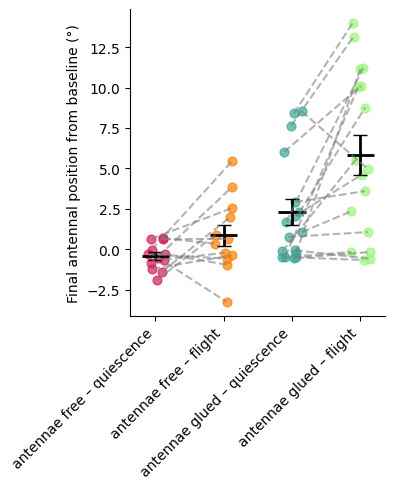

In [30]:
# 5. plot data for Figure S5C
    # Uses the 'final_distance_from_baseline_deg' column from peak_df.
def plot_aa_final_position_scatter(peak_df,labels,colors,figsize=(4, 5),star_offset=1.5):
    plt.figure(figsize=figsize)
    ax = plt.gca()

    # Map condition labels to x positions
    x_pos = {label: i for i, label in enumerate(labels)}

    # Store jittered x positions for connecting paired data
    jitter_dict = {}
    
    # Plot individual flies + mean ± SEM
    for i, label in enumerate(labels):
        subset = peak_df.loc[peak_df['condition'] == label,['date', 'expNumber','final_position_deg']].dropna(subset=['final_position_deg'])
        values = subset['final_position_deg']

        # Jitter individual flies
        x_jitter = (np.random.uniform(-0.15, 0.15, size=len(subset))+ i)
        ax.scatter(x_jitter,values,color=colors[i],alpha=0.7,s=40)

        # Store jitter positions for paired connections
        for date, exp, xj, yval in zip(subset['date'],subset['expNumber'],x_jitter,values):
            jitter_dict.setdefault((date, exp), {})[label] = (xj, yval)

        # Mean ± SEM
        mean_val = np.nanmean(values)
        sem_val = (np.nanstd(values, ddof=1)/ np.sqrt(len(values)))

        ax.hlines(mean_val, i - 0.2, i + 0.2, color='black', linewidth=2)
        ax.errorbar(i,mean_val,yerr=sem_val,fmt='none',ecolor='black',elinewidth=2,capsize=5)

    # Connect paired values
    for (date, exp), cond_dict in jitter_dict.items():
        # Free: quiescence → flight
        if ('antennae free – quiescence' in cond_dict and 'antennae free – flight' in cond_dict):
            x1, y1 = cond_dict['antennae free – quiescence']
            x2, y2 = cond_dict['antennae free – flight']
            ax.plot([x1, x2],[y1, y2],linestyle='--',color='grey',alpha=0.6)

        # Glued: quiescence → flight
        if ('antennae glued – quiescence' in cond_dict and 'antennae glued – flight' in cond_dict):
            x1, y1 = cond_dict['antennae glued – quiescence']
            x2, y2 = cond_dict['antennae glued – flight']
            ax.plot([x1, x2],[y1, y2],linestyle='--',color='grey', alpha=0.6)

    # Formatting
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels,rotation=45,ha='right')
    ax.set_ylabel('Final antennal position from baseline (°)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(top=False,right=False)

    plt.tight_layout()
    plt.show()

plot_aa_final_position_scatter(all_peak_data,labels,colors)


In [31]:
# 6. report stats for final antennal position (Figure S5C)
def test_aa_final_position(peak_df,labels):
    value_col = 'final_position_deg'

    # Define comparisons
    paired_comparisons = [('antennae free – quiescence','antennae free – flight'),
        ('antennae glued – quiescence','antennae glued – flight')]

    unpaired_comparisons = [('antennae free – quiescence','antennae glued – quiescence'),
        ('antennae free – flight','antennae glued – flight')]
    results = []

    # PAIRED COMPARISONS
    for cond1, cond2 in paired_comparisons:
        df1 = peak_df[peak_df['condition'] == cond1][['date', 'expNumber', value_col]].dropna()
        df2 = peak_df[peak_df['condition'] == cond2][['date', 'expNumber', value_col]].dropna()

        # Match the same fly/experiment
        paired = pd.merge(df1,df2,on=['date', 'expNumber'],suffixes=('_1', '_2'))

        vals1 = paired[f'{value_col}_1'].values
        vals2 = paired[f'{value_col}_2'].values

        # Check sample size
        print('\n' + '=' * 60)
        print(f'PAIRED: {cond1} vs {cond2}')
        print(f'n = {len(paired)} paired flies')

        if len(paired) < 3:
            print('Not enough paired observations for testing.')
            continue

        # Test normality of paired differences
        differences = vals2 - vals1
        shapiro_stat, shapiro_p = shapiro(differences)

        print(f'Shapiro-Wilk normality test on differences: 'f'p = {shapiro_p:.4f}')

        # Choose statistical test
        if shapiro_p > 0.05:
            stat, pval = ttest_rel(vals1,vals2)
            test_name = 'Paired t-test'
        else:
            stat, pval = wilcoxon(vals1,vals2)
            test_name = 'Wilcoxon signed-rank'

        print(f'Test: {test_name}')
        print(f'Statistic = {stat:.4f}, 'f'p = {pval:.4f}')

        results.append({
            'comparison': f'{cond1} vs {cond2}',
            'type': 'paired',
            'n': len(paired),
            'normality_p': shapiro_p,
            'test': test_name,
            'statistic': stat,
            'p_value': pval})

    # UNPAIRED COMPARISONS
    for cond1, cond2 in unpaired_comparisons:
        vals1 = peak_df.loc[peak_df['condition'] == cond1,value_col].dropna().values
        vals2 = peak_df.loc[peak_df['condition'] == cond2,value_col].dropna().values

        # Print sample sizes
        print('\n' + '=' * 60)
        print(f'UNPAIRED: {cond1} vs {cond2}')
        print(f'n1 = {len(vals1)}, n2 = {len(vals2)}')

        if len(vals1) < 3 or len(vals2) < 3:
            print('Not enough observations for testing.')
            continue

        # Test normality of each group
        shapiro1_stat, shapiro1_p = shapiro(vals1)
        shapiro2_stat, shapiro2_p = shapiro(vals2)

        print(f'{cond1} Shapiro-Wilk: 'f'p = {shapiro1_p:.4f}')
        print(f'{cond2} Shapiro-Wilk: 'f'p = {shapiro2_p:.4f}')

        # Choose statistical test
        if (shapiro1_p > 0.05 and shapiro2_p > 0.05):
            stat, pval = ttest_ind(vals1,vals2,equal_var=False)
            test_name = "Welch's t-test"
        else:
            stat, pval = mannwhitneyu(vals1,vals2,alternative='two-sided')
            test_name = 'Mann-Whitney U'

        print(f'Test: {test_name}')
        print(f'Statistic = {stat:.4f}, 'f'p = {pval:.4f}')

        #append result to new df
        results.append({'comparison': f'{cond1} vs {cond2}',
            'type': 'unpaired',
            'n': f'{len(vals1)} vs {len(vals2)}',
            'normality_p': (f'{shapiro1_p:.4f}, 'f'{shapiro2_p:.4f}'),
            'test': test_name,
            'statistic': stat,
            'p_value': pval})

    # Return results as DataFrame
    results_df = pd.DataFrame(results)
    return results_df

stats_finalPosition_df = test_aa_final_position(peak_df=all_peak_data,labels=labels)


PAIRED: antennae free – quiescence vs antennae free – flight
n = 12 paired flies
Shapiro-Wilk normality test on differences: p = 0.7595
Test: Paired t-test
Statistic = -1.8623, p = 0.0895

PAIRED: antennae glued – quiescence vs antennae glued – flight
n = 17 paired flies
Shapiro-Wilk normality test on differences: p = 0.2731
Test: Paired t-test
Statistic = -3.3964, p = 0.0037

UNPAIRED: antennae free – quiescence vs antennae glued – quiescence
n1 = 12, n2 = 17
antennae free – quiescence Shapiro-Wilk: p = 0.6342
antennae glued – quiescence Shapiro-Wilk: p = 0.0018
Test: Mann-Whitney U
Statistic = 37.0000, p = 0.0043

UNPAIRED: antennae free – flight vs antennae glued – flight
n1 = 12, n2 = 17
antennae free – flight Shapiro-Wilk: p = 0.8963
antennae glued – flight Shapiro-Wilk: p = 0.1058
Test: Welch's t-test
Statistic = -3.5164, p = 0.0018


# FIGURE 3D: plots the change in APN2's peak Vm response to airflow-mediated antennal deflections during flight and quiescence, both when the antennae are free and when the JONs are blocked.

### reports statistical significance for global mean ± SEM of APN2 Vm for quiescent and flying flies both when the antennae are free, and when the JONs are blocked. Also reports the difference between quiescent and flight Vm within antennae free and JONs blocked groups.


--- Condition averages ---
antennae free – quiescence (n = 12): mean = -6.208, SEM = 0.904
antennae free – flight (n = 12): mean = -5.788, SEM = 0.997
antennae glued – quiescence (n = 17): mean = -1.059, SEM = 0.794
antennae glued – flight (n = 17): mean = -0.945, SEM = 0.875

antennae free – quiescence vs antennae free – flight (n = 12)
  Wilcoxon: stat = 15.0000, p = 0.06396

antennae glued – quiescence vs antennae glued – flight (n = 17)
  Wilcoxon: stat = 59.0000, p = 0.4307

antennae free – quiescence vs antennae glued – quiescence
  n1 = 12 | n2 = 17
  Mann–Whitney U = 27.0000, p = 0.0009706 → significant

antennae free – flight vs antennae glued – flight
  n1 = 12 | n2 = 17
  Mann–Whitney U = 30.0000, p = 0.001545 → significant


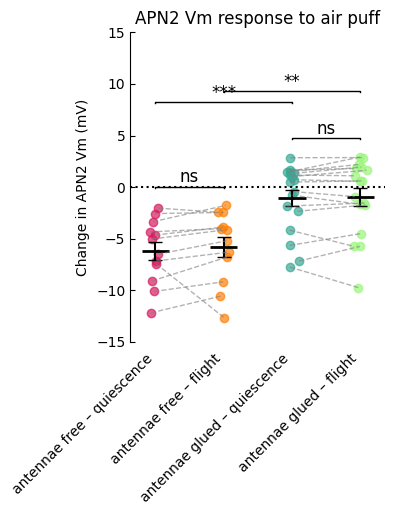

In [126]:
# 1. import data from CSV (function defined in Figure 3A-B)
per_fly_puffResponse = load_puffResponse_from_csv('/Users/nunno/Library/CloudStorage/OneDrive-Vanderbilt/revised_APN2publication_data/Fig3BC_puffResponseTraces.csv')

2. #Usage (ensure file path is correct before plotting):
def plot_vm_peaks_from_df_with_connections(df, condition_order, trace_col='vm_norm_trace', 
                                            colors=['#D81B60', '#FF8107', '#38A996', '#9CF67D'],
                                            center_at=14, sample_interval_ms=10):
    fig, ax = plt.subplots(figsize=(4, 5))
    positions = np.arange(len(condition_order))
    scatter_points = []
    peak_dict = {}
    mean_dict = {}
    
    # Store peak data for dataframe
    peak_data_list = []

    # Extract peak values and metadata
    for i, condition in enumerate(condition_order):
        sub_df = df[df['condition'] == condition]
        peaks, ids = [], []
        for _, row in sub_df.iterrows():
            trace = row[trace_col]
            if isinstance(trace, (list, np.ndarray)) and len(trace) > 0:
                # only look for peak after stimulus onset
                post_stim_trace = np.abs(trace[center_at:])
                local_idx = np.argmax(post_stim_trace)
                idx = center_at + local_idx #converts back to fullt race length
                
                peak_value = trace[idx]
                baseline_value = trace[center_at]
                # Convert index to time relative to center_at (0 time point)
                peak_time = (idx - center_at) * sample_interval_ms

                # Calculate slope (mV change per millisecond – Figure 3F)
                slope = (peak_value - baseline_value) / peak_time
                
                #calculate half-peak latency for Figure 3E
                half_amp = trace[center_at] + 0.5 * (peak_value - trace[center_at])
                response_segment = trace[center_at:idx+1]

                if peak_value >= trace[center_at]:
                    candidates = np.where(response_segment >= half_amp)[0]
                else:
                    candidates = np.where(response_segment <= half_amp)[0]
                
                half_peak_latency_ms = (candidates[0] * sample_interval_ms) if len(candidates) > 0 else np.nan

                
                peaks.append(peak_value)
                ids.append((row['date'], row['expNumber']))
                
                # Store complete peak info
                peak_data_list.append({'date': row['date'],
                    'expNumber': row['expNumber'],
                    'condition': condition,
                    'peak_value': peak_value,
                    'peak_index': idx,
                    'peak_time_ms': peak_time,  # relative to stimulus onset (t=0)
                    'half_peak_latency_ms': half_peak_latency_ms,
                    'slope': slope #(mV/ms)
                })

        peaks = np.array(peaks)
        if len(peaks) > 0:
            sem = np.std(peaks, ddof=1) / np.sqrt(len(peaks))
            mean_val = np.mean(peaks)
    
            mean_dict[condition] = mean_val
    
            xvals = np.random.normal(loc=positions[i], scale=0.05, size=len(peaks))
            ax.scatter(xvals, peaks, color=colors[i], alpha=0.7)
            ax.hlines(mean_val, positions[i] - 0.2, positions[i] + 0.2, color='black', linewidth=2)
            ax.errorbar(positions[i], mean_val, yerr=sem, fmt='none', color='black', capsize=5, linewidth=1.5)
            scatter_points.append((xvals, peaks, ids))
            peak_dict[condition] = dict(zip(ids, peaks))
    
    # Create dataframe from peak data
    peakVm_df = pd.DataFrame(peak_data_list)
    
    # Connect matching (date, expNumber)
    id_to_x_y = {}
    for xvals, yvals, ids in scatter_points:
        for x, y, ident in zip(xvals, yvals, ids):
            if ident not in id_to_x_y:
                id_to_x_y[ident] = []
            id_to_x_y[ident].append((x, y))

    for xy_pairs in id_to_x_y.values():
        if len(xy_pairs) > 1:
            xs, ys = zip(*sorted(xy_pairs, key=lambda pair: pair[0]))
            ax.plot(xs, ys, color='gray', linestyle='--', linewidth=1, alpha=0.6)

    ax.set_xticks(positions)
    ax.set_xticklabels(condition_order, rotation=45, ha='right')
    ax.set_ylabel('Change in APN2 Vm (mV)')
    ax.set_title('APN2 Vm response to air puff')
    ax.axhline(0, linestyle=':', color='black', linewidth=1.5)
    for spine in ['top', 'right', 'bottom']:
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis='x', bottom=False, top=False)
    ax.tick_params(axis='y', direction='in')

    # Print mean ± SEM for each condition
    print("\n--- Condition averages ---")
    for condition in condition_order:
        peaks = list(peak_dict[condition].values())
        mean = np.mean(peaks)
        sem = np.std(peaks, ddof=1) / np.sqrt(len(peaks)) if len(peaks) > 1 else 0
        print(f"{condition} (n = {len(peaks)}): mean = {mean:.3f}, SEM = {sem:.3f}")

    # Paired comparisons (within group)
    paired_groups = [
        ('antennae free – quiescence', 'antennae free – flight', 't-test'),
        ('antennae glued – quiescence', 'antennae glued – flight', 'wilcoxon')]

    for cond_q, cond_f, test_type in paired_groups:
        ids_q = set(peak_dict[cond_q].keys())
        ids_f = set(peak_dict[cond_f].keys())
        matched_ids = sorted(ids_q & ids_f)

        q_vals = [peak_dict[cond_q][i] for i in matched_ids]
        f_vals = [peak_dict[cond_f][i] for i in matched_ids]

        print(f"\n{cond_q} vs {cond_f} (n = {len(matched_ids)})")

        stat, p = wilcoxon(q_vals, f_vals)
        print(f"  Wilcoxon: stat = {stat:.4f}, p = {p:.4g}")

        # Significance annotation
        x1 = condition_order.index(cond_q)
        x2 = condition_order.index(cond_f)
        max_val = max(max(q_vals), max(f_vals))
        y_min, y_max = ax.get_ylim()
        y_buffer = 0.05 * (y_max - y_min)
        h = max_val + y_buffer
        h_star = h + 0.01 * (y_max - y_min)

        if p < 0.001:
            star = '***'
        elif p < 0.01:
            star = '**'
        elif p < 0.05:
            star = '*'
        else:
            star = 'ns'

        if star == 'ns':
            h = max_val + 0.1 * (y_max - y_min)         # lower bar height
            h_star = h + 0.05 * (y_max - y_min)         # lower text position
        else:
            h = max_val + 0.05 * (y_max - y_min)         # original/default
            h_star = h + 0.01 * (y_max - y_min)

        ax.plot([x1, x1, x2, x2], [h, h + 0.1, h + 0.1, h], color='black', linewidth=1)
        ax.text((x1 + x2) / 2, h + 0.13, star, ha='center', va='bottom', fontsize=12, color='black')

    # Unpaired comparisons (across groups) 
    unpaired_groups = [
        ('antennae free – quiescence', 'antennae glued – quiescence'),
        ('antennae free – flight', 'antennae glued – flight')]

    for cond1, cond2 in unpaired_groups:
        vals1 = list(peak_dict[cond1].values())
        vals2 = list(peak_dict[cond2].values())
        stat, p = mannwhitneyu(vals1, vals2, alternative='two-sided')

        x1 = condition_order.index(cond1)
        x2 = condition_order.index(cond2)
        max_val = max(max(vals1), max(vals2))
        y_min, y_max = ax.get_ylim()
        y_buffer = 0.05 * (y_max - y_min)
        h = max_val + y_buffer
        h_star = h + 0.01 * (y_max - y_min)

        if p < 0.001:
            star = '***'
        elif p < 0.01:
            star = '**'
        elif p < 0.05:
            star = '*'
        else:
            star = 'ns'

        if star != 'ns':
            h = max_val + 0.275 * (y_max - y_min)         # lower bar height
            h_star = h + 0.075 * (y_max - y_min)         # lower text position
        else:
            h = max_val + 0.05 * (y_max - y_min)         # original/default
            h_star = h + 0.01 * (y_max - y_min)

        ax.plot([x1, x1, x2, x2], [h, h + 0.1, h + 0.1, h], color='black', linewidth=1)
        ax.text((x1 + x2) / 2, h + 0.13, star, ha='center', va='bottom', fontsize=12, color='black')

        print(f"\n{cond1} vs {cond2}")
        print(f"  n1 = {len(vals1)} | n2 = {len(vals2)}")
        print(f"  Mann–Whitney U = {stat:.4f}, p = {p:.4g} → {'significant' if p < 0.05 else 'not significant'}")

    # Pad the y-axis for visibility of annotations
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min, y_max + 0.4 * (y_max - y_min))
    ax.set_ylim(-15, 15)

    plt.tight_layout(rect=[0, 0, 1, 1.05])
    plt.show()

    return peakVm_df

#Call function:
peakVm_df= plot_vm_peaks_from_df_with_connections(
    df=per_fly_puffResponse,
    condition_order=[
        'antennae free – quiescence',
        'antennae free – flight',
        'antennae glued – quiescence',
        'antennae glued – flight'],
    trace_col='vm_norm_trace', colors=['#D81B60', '#FF8107', '#38A996', '#9CF67D'])

# FIGURE 3E: plots APN2 membrane potential half-peak latency to airflow mediated antennal deflections 
## reports statistical significance for global mean ± SEM of APN2 Vm for quiescent and flying flies both when the antennae are free, and when the JONs are blocked. Also reports the difference between quiescent and flight Vm within antennae free and JONs blocked groups.

antennae free – quiescence vs antennae free – flight, p-value = 0.317311
antennae glued – quiescence vs antennae glued – flight, p-value = 0.523003
antennae free – quiescence vs antennae glued – quiescence, p-value = 0.000016
antennae free – flight vs antennae glued – flight, p-value = 0.000011


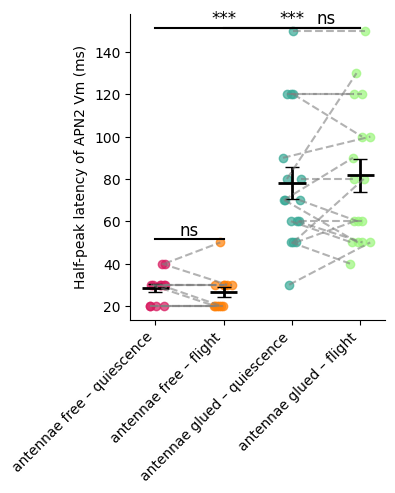

In [127]:
# 1. uses data stored in new dataframe (peakVm_df)
    # defined in cell plotting Figure 3D)

#2. plot half peak latency
def plot_half_peak_latency_scatter_nonparam_colored(vm_df, labels, colors, figsize=(4,5), star_offset=1.5):

    plt.figure(figsize=figsize)
    ax = plt.gca()

    # Map labels to x positions
    x_pos = {label:i for i, label in enumerate(labels)}

    # Store jittered x positions for connecting pairs
    jitter_dict = {}

    # Plot scatter + mean ± SEM using custom colors
    for i, label in enumerate(labels):
        subset = vm_df.loc[vm_df['condition'] == label, ['date','expNumber','half_peak_latency_ms']].dropna()
 
    
        x_jitter = np.random.uniform(-0.15, 0.15, size=len(subset)) + i

        ax.scatter(x_jitter, subset['half_peak_latency_ms'], color=colors[i], alpha=0.7)

        # store jitter positions by identifier
        for date, exp, xj, yval in zip(subset['date'], subset['expNumber'], x_jitter, subset['half_peak_latency_ms']):
            jitter_dict.setdefault((date, exp), {})[label] = (xj, yval)

        # mean ± SEM
        mean_val = np.nanmean(subset['half_peak_latency_ms'])
        sem_val = np.nanstd(subset['half_peak_latency_ms'])/np.sqrt(len(subset))
        ax.hlines(mean_val, i-0.2, i+0.2, color='black', linewidth=2)
        ax.errorbar(i, mean_val, yerr=sem_val, fmt='none', ecolor='black', elinewidth=2, capsize=5)


    # Connect paired values within free and glued
    for (date, exp), cond_dict in jitter_dict.items():
        # free condition
        if 'antennae free – quiescence' in cond_dict and 'antennae free – flight' in cond_dict:
            x1, y1 = cond_dict['antennae free – quiescence']
            x2, y2 = cond_dict['antennae free – flight']
            ax.plot([x1, x2], [y1, y2], linestyle='--', color='grey', alpha=0.6)

        # glued condition
        if 'antennae glued – quiescence' in cond_dict and 'antennae glued – flight' in cond_dict:
            x1, y1 = cond_dict['antennae glued – quiescence']
            x2, y2 = cond_dict['antennae glued – flight']
            ax.plot([x1, x2], [y1, y2], linestyle='--', color='grey', alpha=0.6)

    # Define comparisons
    paired_free = ('antennae free – quiescence', 'antennae free – flight')
    paired_glued = ('antennae glued – quiescence', 'antennae glued – flight')
    unpaired_quiescence = ('antennae free – quiescence', 'antennae glued – quiescence')
    unpaired_flight = ('antennae free – flight', 'antennae glued – flight')

    comparisons = [paired_free, paired_glued, unpaired_quiescence, unpaired_flight]

    # Annotate significance
    for pair in comparisons:
        df1 = vm_df[vm_df['condition'] == pair[0]]
        df2 = vm_df[vm_df['condition'] == pair[1]]

        # Decide if this is paired (same flies) or unpaired (different flies)
        paired = ('free' in pair[0] and 'free' in pair[1]) or ('glued' in pair[0] and 'glued' in pair[1])

        if paired: #flight vs quiesence
            #combines seperate flight and quiesence data rows into a singular row in the df, with appropriate columns
            merged = pd.merge(df1, df2, on=['date','expNumber'], suffixes=('_1','_2')) 
            vals1 = merged['half_peak_latency_ms_1'].values
            vals2 = merged['half_peak_latency_ms_2'].values

            diffs = vals1 - vals2
            
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=UserWarning)
                stat, pval = wilcoxon(vals1, vals2)

        else:
            # unpaired: just take all values
            vals1 = df1['half_peak_latency_ms'].dropna().values
            vals2 = df2['half_peak_latency_ms'].dropna().values
            diffs = None  # not defined for unpaired

            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=UserWarning)
                stat, pval = mannwhitneyu(vals1, vals2, alternative='two-sided')

        print(f"{pair[0]} vs {pair[1]}, p-value = {pval:.6f}")

        # plot significance star
        x1, x2 = x_pos[pair[0]], x_pos[pair[1]]
        y = max(np.nanmax(vals1), np.nanmax(vals2)) + star_offset
        ax.plot([x1, x1, x2, x2], [y-0.1, y, y, y-0.1], lw=1.5, color='black')  # bracket
        if pval < 0.001:
            text = '***'
        elif pval < 0.01:
            text = '**'
        elif pval < 0.05:
            text = '*'
        else:
            text = 'ns'
        ax.text((x1+x2)/2, y + 0.1, text, ha='center', va='bottom', fontsize=12)

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Half-peak latency of APN2 Vm (ms)') #(indices from puff onset)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(top=False, right=False)
    
    plt.tight_layout()
    plt.show()

#Call function:
colors = ['#D81B60', '#FF8107', '#38A996', '#9CF67D']

plot_half_peak_latency_scatter_nonparam_colored(peakVm_df, labels, colors)

# FIGURE 3F: plots slope of APN2 membrane potential response to air puff mediated antennal deflections 
### reports statistical significance for global mean ± SEM of APN2 Vm for quiescent and flying flies both when the antennae are free, and when the JONs are blocked. Also reports the difference between quiescent and flight Vm within antennae free and JONs blocked groups.

antennae free – quiescence vs antennae free – flight, p-value = 0.266113
antennae glued – quiescence vs antennae glued – flight, p-value = 0.487381
antennae free – quiescence vs antennae glued – quiescence, p-value = 0.002087
antennae free – flight vs antennae glued – flight, p-value = 0.001798


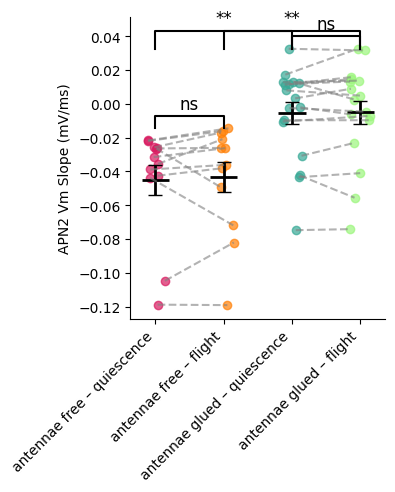

In [130]:
# 1. uses data stored in new dataframe (peakVm_df)
    # defined in cell plotting Figure 3D)

# 2. plots changes in slope
def plot_vm_slope_scatter_with_stats(vm_df, labels, colors, figsize=(4,5), star_offset=0.06):
    #set up figure
    plt.figure(figsize=figsize)
    ax = plt.gca()

    #map labels to x positions
    x_pos = {label: i for i, label in enumerate(labels)}
    #create dictionary for jittered indicies
    jitter_dict = {}

    # Scatter plot + mean ± SEM
    for i, label in enumerate(labels):
        subset = vm_df.loc[vm_df['condition'] == label, ['date','expNumber','slope']].dropna()
    
        x_jitter = np.random.uniform(-0.15, 0.15, size=len(subset)) + i

        ax.scatter(x_jitter, subset['slope'], color=colors[i], alpha=0.7)

        # store jitter positions by identifier
        for date, exp, xj, yval in zip(subset['date'], subset['expNumber'], x_jitter, subset['slope']):
            jitter_dict.setdefault((date, exp), {})[label] = (xj, yval)

        # mean ± SEM
        mean_val = np.nanmean(subset['slope'])
        sem_val = np.nanstd(subset['slope'])/np.sqrt(len(subset))
        ax.hlines(mean_val, i-0.2, i+0.2, color='black', linewidth=2)
        ax.errorbar(i, mean_val, yerr=sem_val, fmt='none', ecolor='black', elinewidth=2, capsize=5)

    # Connect paired points within free and glued
    for (date, exp), cond_dict in jitter_dict.items():
        # free
        if 'antennae free – quiescence' in cond_dict and 'antennae free – flight' in cond_dict:
            x1, y1 = cond_dict['antennae free – quiescence']
            x2, y2 = cond_dict['antennae free – flight']
            ax.plot([x1, x2], [y1, y2], linestyle='--', color='grey', alpha=0.6)
        # glued
        if 'antennae glued – quiescence' in cond_dict and 'antennae glued – flight' in cond_dict:
            x1, y1 = cond_dict['antennae glued – quiescence']
            x2, y2 = cond_dict['antennae glued – flight']
            ax.plot([x1, x2], [y1, y2], linestyle='--', color='grey', alpha=0.6)

    # Define comparisons
    paired_free = ('antennae free – quiescence', 'antennae free – flight')
    paired_glued = ('antennae glued – quiescence', 'antennae glued – flight')
    unpaired_quiescence = ('antennae free – quiescence', 'antennae glued – quiescence')
    unpaired_flight = ('antennae free – flight', 'antennae glued – flight')
    comparisons = [paired_free, paired_glued, unpaired_quiescence, unpaired_flight]

    # Annotate significance
    for pair in comparisons:
        vals1 = vm_df.loc[vm_df['condition']==pair[0], 'slope'].dropna()
        vals2 = vm_df.loc[vm_df['condition']==pair[1], 'slope'].dropna()

        # choose test
        if 'free' in pair[0] and 'free' in pair[1]:
            stat, pval = wilcoxon(vals1, vals2)
        elif 'glued' in pair[0] and 'glued' in pair[1]:
            stat, pval = wilcoxon(vals1, vals2)
        else:
            stat, pval = mannwhitneyu(vals1, vals2, alternative='two-sided')

        print(f"{pair[0]} vs {pair[1]}, p-value = {pval:.6f}")

        # plot significance star
        x1, x2 = x_pos[pair[0]], x_pos[pair[1]]

        # compute max y of these two groups
        y_max = max(vals1.max(), vals2.max())
        y_min = min(vals1.min(), vals2.min())

        # scale offsets by data range
        offset = 0.07 * (y_max - y_min)  # 5% of the y-range

        # plot bracket
        ax.plot([x1, x1, x2, x2], [y_max, y_max+offset, y_max+offset, y_max], lw=1.5, color='black')

        # plot stars just above bracket
        star = '***' if pval<0.001 else '**' if pval<0.01 else '*' if pval<0.05 else 'ns'
        ax.text((x1+x2)/2, y_max + 1.2*offset, star, ha='center', va='bottom', fontsize=12)


    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('APN2 Vm Slope (mV/ms)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(top=False, right=False)


    plt.tight_layout()
    plt.show()

#Call function:
labels = [
    'antennae free – quiescence',
    'antennae free – flight',
    'antennae glued – quiescence',
    'antennae glued – flight']

colors = ['#D81B60', '#FF8107', '#38A996', '#9CF67D']

plot_vm_slope_scatter_with_stats(peakVm_df, labels, colors) #uses same CSV as 2G

# FIGURE 4A-C: Active movements

## !! run analysis in MATLAB !!

In [20]:
### Figure 4 A-B: Active movement plotting

## 1. download MAT files containing Vm and antennal data correlated to active movement indicies:
# '200ms_LandR_activeMoves_glue_Qtrials.mat'
# '200ms_LandR_activeMoves_noGlue_Qtrials.mat'
# 'control_LandR_activeMoves_glue_Qtrials.mat'
# 'control_LandR_activeMoves_noGlue_Qtrials.mat'

## 2. in MATLAB load data file containing active movement indicies
# ex) data = load('200ms_LandR_activeMoves_glue_Qtrials.mat')

## 3. combine experiment date and experiment number to have
# unique identifiers for each cell (N)
#  ex) groupedTrials = group_trials_by_date_exp(data))

## 4. calculate the average Laa, Raa, Lvm, Rvm across trials for each experiment
# ex) comboAvg = compute_combo_averages(data,groupedTrials,buffer)
    # buffer = 20 (amount of samples to plot before and after ROI)

## 5. plots Laa, Raa, Lvm, Rvm traces, with the group average overlaid
# B) colors of aa match vm, all hyperpolarizing trials are one color and depolarizing trials another color
    # ex) plot_crossflyTraces_bimodalColor(comboAvg)


### Figure 4C: Active movement quantification

# 6. Download MAT files containing calculated area under the curve for each condition:
# control_noGlueQ_Vm_AUCs.mat
# control_glueQ_Vm_AUCs.mat
# noGlueQ_Vm_AUCs.mat
# glueQ_Vm_AUCs.mat

## 7. plot quantification (APN2 Vm |AUC|)
# combines LVm (ipsi) and RVm (contra) values for each condition: (control no glue, no glue, control glue, glue)
# the original sign (positive/depolarizing VS negative/hyperpolarizing) of each dot is represented by its respective color 
# ex) plot_auc_abs_combined_signColored('control_noGlueQ_Vm_AUCs.mat', 'noGlueQ_Vm_AUCs.mat', 'control_glueQ_Vm_AUCs.mat', 'glueQ_Vm_AUCs.mat')

## 8. compute stats
# ex) paired_auc_test_shapiro('control_noGlueQ_Vm_AUCs.mat', 'noGlueQ_Vm_AUCs.mat', 'control_glueQ_Vm_AUCs.mat', 'glueQ_Vm_AUCs.mat')
    # need to downlaod the swtest package from MATLAB community center,prior

### Comapre movement frequencies

## 9. Download MAT files containing movement stats, categorized by individual APN2 recordings:
# unique_noGlueMoveCount.mat
# unique_glueMoveCount.mat

## 10. calculate the average movement frequency across all cells, with the associated SEM values
#glueMean = mean(glueMovesPerSec);
#glueSEM = std(glueMovesPerSec) / sqrt(length(glueMovesPerSec));
#noGlueMean = mean(noGlueMovesPerSec);
#noGlueSEM = std(noGlueMovesPerSec) / sqrt(length(noGlueMovesPerSec));


# Figure 5 D & F: plots per-fly average antennal response to optogenetic inactivation (blue) and activation (red) experiments, as well as appropriate control experiments.

### reports how many flies are plotted in each group

controlNOFlight_inactivation: 10 flies plotted
controlFlight_inactivation: 10 flies plotted
24C06NOFlight_inactivation: 11 flies plotted
24C06Flight_inactivation: 11 flies plotted
controlNOFlight_activation: 15 flies plotted
controlFlight_activation: 11 flies plotted
24C06NOFlight_activation: 11 flies plotted
24C06Flight_activation: 12 flies plotted


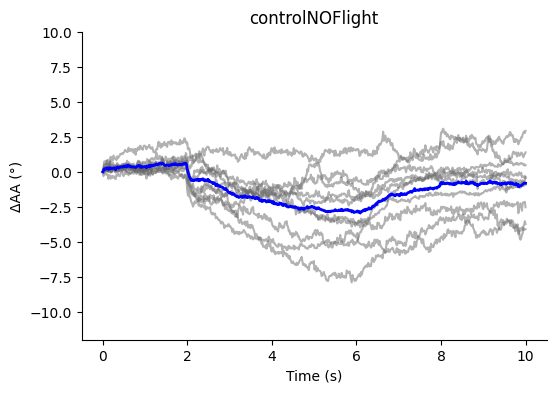

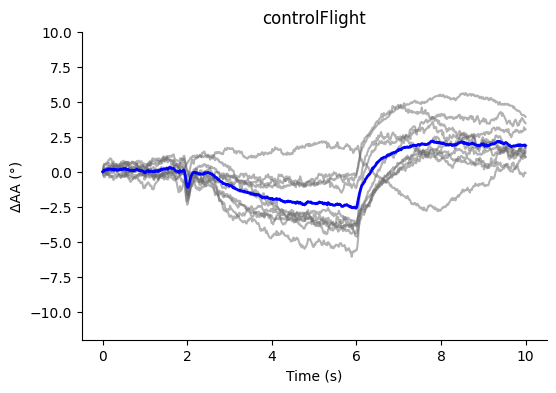

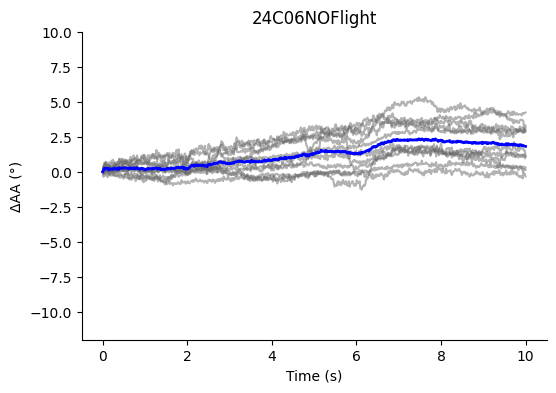

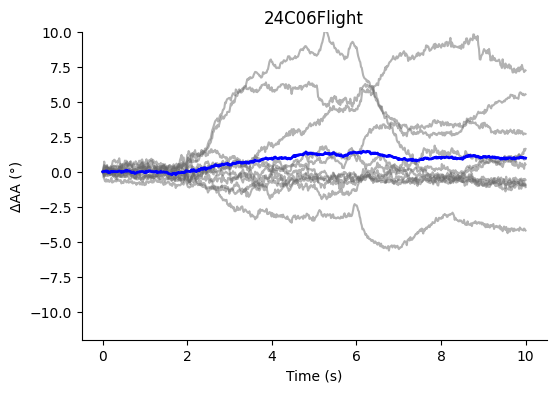

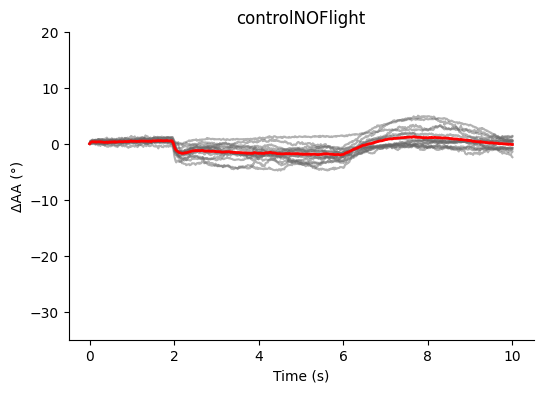

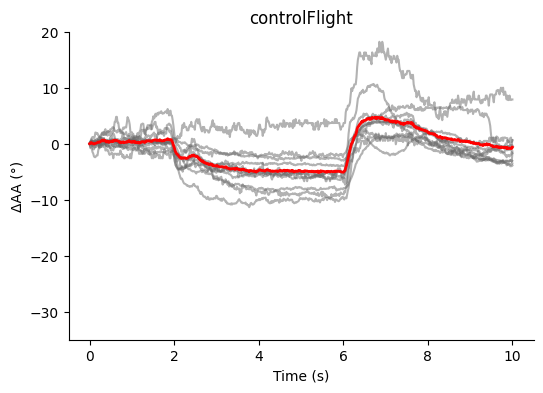

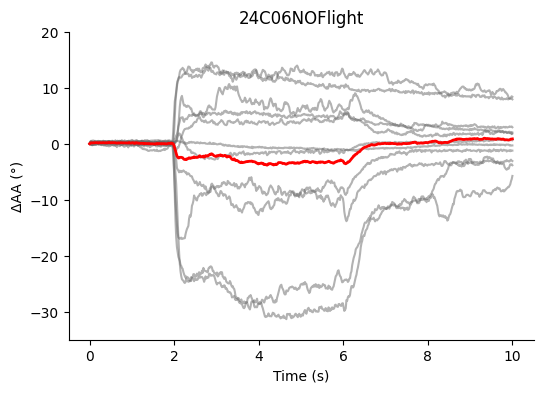

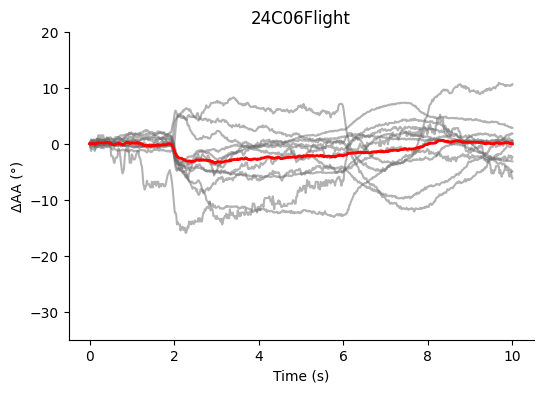

In [90]:
#1. load CSVs (iactivation and activation) & parse arrays
def load_minimal_csv(path):
    df = pd.read_csv(path)
    def parse_aa(x):
        if pd.isna(x):
            return np.array([])
        try:
            return np.array(json.loads(x))
        except:
            return np.array([])
    df['aa'] = df['aa'].apply(parse_aa)
    return df

def load_all_conditions(allConditionsNames, save_dir):
    allConditions_inactivation = []
    allConditions_activation = []
    for name in allConditionsNames:
        # Inactivation file
        inact_file = f"{save_dir}/inactivation_{name}.csv"
        try:
            df_inact = load_minimal_csv(inact_file)
            allConditions_inactivation.append(df_inact)
        except FileNotFoundError:
            print(f"Missing: {inact_file}")

        # Activation file
        act_file = f"{save_dir}/activation_{name}.csv"
        try:
            df_act = load_minimal_csv(act_file)
            allConditions_activation.append(df_act)
        except FileNotFoundError:
            print(f"Missing: {act_file}")
            
    return allConditions_inactivation, allConditions_activation
    
#Usage:
allConditionsNames = ['controlNOFlight', 'controlFlight', '24C06NOFlight', '24C06Flight']
save_dir = "/Users/nunno/Library/CloudStorage/OneDrive-Vanderbilt/ThesisWork/APN2/BehavioralAnalysisCode/Aim1/data"
allConditions_inactivation, allConditions_activation = load_all_conditions(allConditionsNames, save_dir)

#plot INACTIVATION traces
skip_points = 8 #does not plot the first 8 datapoints - due to auto-exposure lighting discrepencies when video is initiated
for i, condition in enumerate(allConditions_inactivation):
    fig, ax = plt.subplots(figsize=(6,4))
    overallAvgList = []
    flies_plotted = 0

    #gets average for each fly
    for fly_id, group in condition.groupby('fly'):
        fly_traces = []
        for tr in group['aa'].to_list():
            if len(tr) == 0:
                continue
            tr = np.array(tr)

            # Skip first points
            tr = tr[skip_points:]

            # Baseline subtract so first point is 0
            baseline = tr[0]
            tr = tr - baseline

            fly_traces.append(tr)

        if len(fly_traces) == 0:
            continue

        #keeps count of how many flies are plotted in each group
        flies_plotted +=1

        ## Pad traces to same length
        max_len = max(len(tr) for tr in fly_traces)
        fly_traces_padded = np.array([np.pad(tr, (0, max_len - len(tr)), constant_values=np.nan)
                                      for tr in fly_traces])

        # Compute average trace for this fly
        flyAvg = np.nanmean(fly_traces_padded, axis=0)
        overallAvgList.append(flyAvg)

        # Plot individual fly trials (semi-transparent)
        ax.plot(np.linspace(0, 10, len(flyAvg)), flyAvg, color = '0.4', alpha=0.5)

    # Overall mean across flies
    if overallAvgList:
        max_len = max(len(tr) for tr in overallAvgList)
        overall_padded = np.array([np.pad(tr, (0, max_len - len(tr)), constant_values=np.nan)
                                   for tr in overallAvgList])
        #plots all trials
        overallMean = np.nanmean(overall_padded, axis=0)
        ax.plot(np.linspace(0, 10, len(overallMean)), overallMean, 'b', lw=2, label='Overall Mean')
        
    ax.spines[['top','right']].set_visible(False)
    ax.set_ylim([-12,10])
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('ΔAA (°)')
    ax.set_title(allConditionsNames[i])

    print(f"{allConditionsNames[i]+'_inactivation'}: {flies_plotted} flies plotted")


#ACTIVATION
skip_points = 8 #does not plot the first 8 datapoints - due to auto-exposure lighting discrepencies between frames
for i, condition in enumerate(allConditions_activation):
    fig, ax = plt.subplots(figsize=(6,4))
    overallAvgList = []
    flies_plotted = 0

    for fly_id, group in condition.groupby('fly'):
        fly_traces = []
        for tr in group['aa'].to_list():
            if len(tr) == 0:
                continue
            tr = np.array(tr)

            # Skip first points
            tr = tr[skip_points:]

            # Baseline subtract so first point is 0
            baseline = tr[0]
            tr = tr - baseline

            fly_traces.append(tr)

        if len(fly_traces) == 0:
            continue

        flies_plotted +=1

        # Pad traces to same length
        max_len = max(len(tr) for tr in fly_traces)
        fly_traces_padded = np.array([np.pad(tr, (0, max_len - len(tr)), constant_values=np.nan)
                                      for tr in fly_traces])

        # Compute average trace for this fly
        flyAvg = np.nanmean(fly_traces_padded, axis=0)
        overallAvgList.append(flyAvg)

        # Plot individual fly trials (semi-transparent)
        ax.plot(np.linspace(0, 10, len(flyAvg)), flyAvg, color = '0.4', alpha=0.5)

    # Overall mean across flies
    if overallAvgList:
        max_len = max(len(tr) for tr in overallAvgList)
        overall_padded = np.array([np.pad(tr, (0, max_len - len(tr)), constant_values=np.nan)
                                   for tr in overallAvgList])
        #plots all trials
        overallMean = np.nanmean(overall_padded, axis=0)
        ax.plot(np.linspace(0, 10, len(overallMean)), overallMean, 'r', lw=2, label='Overall Mean')
        
    ax.spines[['top','right']].set_visible(False)
    ax.set_ylim([-35,20])
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('ΔAA (°)')
    ax.set_title(allConditionsNames[i])

    print(f"{allConditionsNames[i]+'_activation'}: {flies_plotted} flies plotted")

# Figure S6: plots the absolute value of every per-fly average antennal trace for flying and quiescent flies during optogenetic activation experiments.

### reports how many flies were plotted in each group

controlNOFlight_ABSactivation: 11 flies plotted
controlFlight_ABSactivation: 12 flies plotted


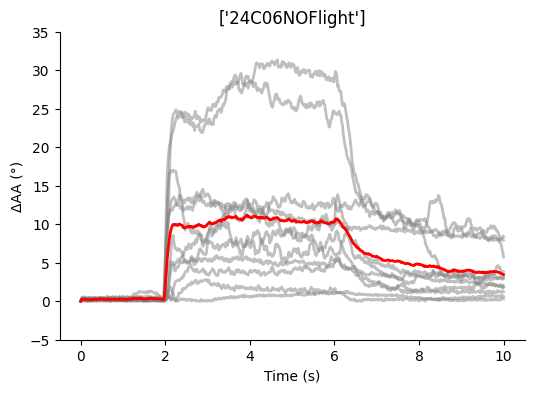

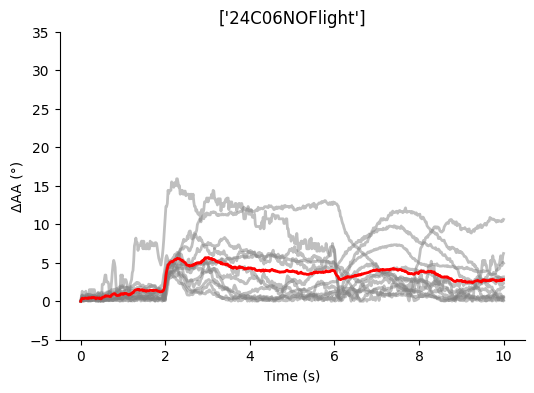

In [22]:
#same general code as aboe, just plots the absolute value of the traces for APN2 activation
skip_points = 8 #does not plot the first 8 datapoints - due to auto-exposure lighting discrepencies between frames
for i, condition in enumerate(allConditions_activation[2:]):
    fig, ax = plt.subplots(figsize=(6,4))
    overallAvgList = []
    flies_plotted = 0

    for fly_id, group in condition.groupby('fly'):
        fly_traces = []
        for tr in group['aa'].to_list():
            if len(tr) == 0:
                continue
            tr = np.array(tr)

            # Skip first points
            tr = tr[skip_points:]

            # Baseline subtract so first point is 0
            baseline = tr[0]
            tr = tr - baseline

            fly_traces.append(tr)

        if len(fly_traces) == 0:
            continue

        flies_plotted +=1

        # Pad traces to same length
        max_len = max(len(tr) for tr in fly_traces)
        fly_traces_padded = np.array([np.pad(tr, (0, max_len - len(tr)), constant_values=np.nan)
                                      for tr in fly_traces])

        # Compute average trace for this fly
        flyAvg = np.nanmean(fly_traces_padded, axis=0)
        overallAvgList.append(flyAvg)

        #plots absolute value of fly trials
        ax.plot(np.linspace(0, 10, len(flyAvg)), abs(flyAvg), 'grey', lw=2, alpha=0.5)

    # Overall mean across flies
    if overallAvgList:
        max_len = max(len(tr) for tr in overallAvgList)
        overall_padded = np.array([np.pad(tr, (0, max_len - len(tr)), constant_values=np.nan)
                                   for tr in overallAvgList])
        #plots absolute value of every trial
        overallMean = np.nanmean(abs(overall_padded), axis=0)
        ax.plot(np.linspace(0, 10, len(overallMean)), overallMean, 'red', lw=2, label='Overall Mean')
        
    ax.spines[['top','right']].set_visible(False)
    ax.set_ylim([-5,35])
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('ΔAA (°)')
    ax.set_title(allConditionsNames[2:3])

    print(f"{allConditionsNames[i]+'_ABSactivation'}: {flies_plotted} flies plotted")

# Figure 5 E & G: plots the quantification of optogenetic activation or inactivation (depending on which data file you use)

### reports statistical significance for global mean ± SEM of APN2 Vm for quiescent and flying flies both when the antennae are free, and when the JONs are blocked. Also reports the difference between quiescent and flight Vm within antennae free and JONs blocked groups.

control: controlNOFlight vs controlFlight
 mean:3.4485182382166863, SEM:0.34342527984186483
  Test used: t-test, stat=-2.333, p=0.037

24C06: 24C06NOFlight vs 24C06Flight
 mean:3.4485182382166863, SEM:0.34342527984186483
  Test used: Mann-Whitney, stat=98.000, p=0.053

NOFlight: controlNOFlight vs 24C06NOFlight
 mean:3.4485182382166863, SEM:0.34342527984186483
  Test used: Mann-Whitney, stat=26.000, p=0.004

Flight: controlFlight vs 24C06Flight
 mean:3.4485182382166863, SEM:0.34342527984186483
  Test used: Mann-Whitney, stat=75.000, p=0.601



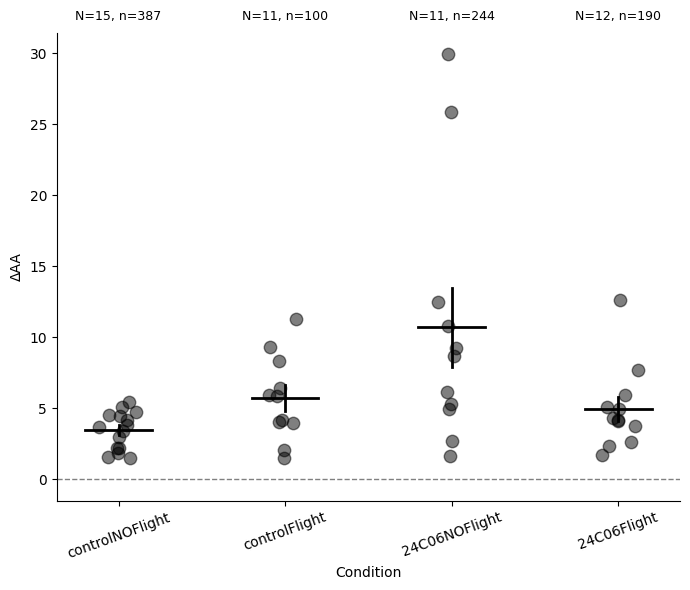

In [24]:
############# choose inactivation OR activation to import. cannot have both uncommented at the same time
##INACTIVATION (Figure 5E)
#df_plot_all = pd.read_csv('/Users/nunno/Library/CloudStorage/OneDrive-Vanderbilt/revised_APN2publication_data/df_plotAvgs_inactivation.csv')
#############
##ACTIVATION (Figure 5G)
df_plot_all = pd.read_csv('/Users/nunno/Library/CloudStorage/OneDrive-Vanderbilt/revised_APN2publication_data/df_plotAvgs_activation.csv')
#############

# Map genotypes to their Flight/NOFlight condition names
genotype_conditions = {
    'control': ['controlNOFlight', 'controlFlight'],
    '24C06': ['24C06NOFlight', '24C06Flight']}

# Setup plot
fig, ax = plt.subplots(figsize=(7,6))
jitter_strength = 0.05
condition_to_x = {name: i for i, name in enumerate(allConditionsNames)}

# Add jittered x positions
df_plot_all['x_jittered'] = 0.0
for cond in allConditionsNames:
    mask = df_plot_all['condition'] == cond
    n_points = mask.sum()
    jitter = np.random.normal(0, jitter_strength, size=n_points)
    df_plot_all.loc[mask, 'x_jittered'] = condition_to_x[cond] + jitter

# Scatter plot
ax.scatter(df_plot_all['x_jittered'], df_plot_all['relAngle'], color='black', s=80, alpha=0.5)

# Compute mean ± SEM per condition
stats_df = df_plot_all.groupby('condition')['relAngle'].agg(['mean','sem'])

for cond, row in stats_df.iterrows():
    x = condition_to_x[cond]
    mean_val = row['mean']
    sem_val = row['sem']
    ax.plot([x - 0.2, x + 0.2], [mean_val, mean_val], color='black', lw=2)
    ax.plot([x, x], [(mean_val - sem_val), (mean_val + sem_val)], color='black', lw=2)

genotype_conditions = {
    'control': ['controlNOFlight', 'controlFlight'],
    '24C06': ['24C06NOFlight', '24C06Flight']}

# --- Within-genotype Flight vs NoFlight ---
for genotype, (flight_cond, noflight_cond) in genotype_conditions.items():
    # Get data
    data1 = df_plot_all[df_plot_all['condition'] == flight_cond]['relAngle']
    data2 = df_plot_all[df_plot_all['condition'] == noflight_cond]['relAngle']

    # Normality
    p1 = shapiro(data1).pvalue
    p2 = shapiro(data2).pvalue
    normal1 = p1 > 0.05
    normal2 = p2 > 0.05

    # Equal variance
    p_var = levene(data1, data2).pvalue
    equal_var = p_var > 0.05

    # Choose test
    if normal1 and normal2:
        stat, pval = ttest_ind(data1, data2, equal_var=equal_var)
        test_name = 't-test'
    else:
        stat, pval = mannwhitneyu(data1, data2, alternative='two-sided')
        test_name = 'Mann-Whitney'

    print(f"{genotype}: {flight_cond} vs {noflight_cond}\n mean:{mean_val}, SEM:{sem_val}")
    #print(f"  Normality -> {flight_cond}: {normal1}, {noflight_cond}: {normal2}")
    #print(f"  Equal variance: {equal_var}")
    print(f"  Test used: {test_name}, stat={stat:.3f}, p={pval:.3f}\n")

#print("All conditions in df_plot_all:", df_plot_all['condition'].unique())

# --- Between-genotype comparisons for Flight and NoFlight separately ---
flight_conds = ['controlFlight', '24C06Flight']
noflight_conds = ['controlNOFlight', '24C06NOFlight']

# Then loop over
for cond_type, conds in [('NOFlight', noflight_conds), ('Flight', flight_conds)]:
    data1 = df_plot_all[df_plot_all['condition'] == conds[0]]['relAngle']
    data2 = df_plot_all[df_plot_all['condition'] == conds[1]]['relAngle']

    # Normality
    p1 = shapiro(data1).pvalue
    p2 = shapiro(data2).pvalue
    normal1 = p1 > 0.05
    normal2 = p2 > 0.05

    # Equal variance
    p_var = levene(data1, data2).pvalue
    equal_var = p_var > 0.05

    # Choose test
    if normal1 and normal2:
        stat, pval = ttest_ind(data1, data2, equal_var=equal_var)
        test_name = 't-test'
    else:
         stat, pval = mannwhitneyu(data1, data2, alternative='two-sided')
         test_name = 'Mann-Whitney'

    print(f"{cond_type}: {conds[0]} vs {conds[1]}\n mean:{mean_val}, SEM:{sem_val}")
    #print(f"  Normality -> {conds[0]}: {normal1}, {conds[1]}: {normal2}")
    #print(f"  Equal variance: {equal_var}")
    print(f"  Test used: {test_name}, stat={stat:.3f}, p={pval:.3f}\n")



# Annotate N (flies) and n (trials) per condition
for i, cond in enumerate(allConditionsNames):
    df_cond = df_plot_all[df_plot_all['condition'] == cond]
    N_flies = df_cond['fly'].nunique()  # number of unique flies
    n_trials = df_cond['nTrials'].sum() if 'nTrials' in df_cond.columns else len(df_cond)  # fallback to rows
    ax.text(i, ax.get_ylim()[1] + 1, f"N={N_flies}, n={n_trials}", ha='center', fontsize=9)


# Format axes
ax.set_xticks(range(len(allConditionsNames)))
ax.set_xticklabels(allConditionsNames, rotation=20)
ax.set_ylabel('ΔAA')
ax.set_xlabel('Condition')
ax.spines[['top','right']].set_visible(False)
ax.axhline(0, color='gray', linestyle='--', lw=1)
fig.tight_layout()
plt.show()

# Figure S7: plots puff peak amplitudes during quiescence and flight both when the antennae are free and when the JONs are blocked. 
### reports statistical significance for global mean ± SEM of puff peak amplitude for trials with quiescent and flying flies, both when the antennae are free & when the JONs are blocked.

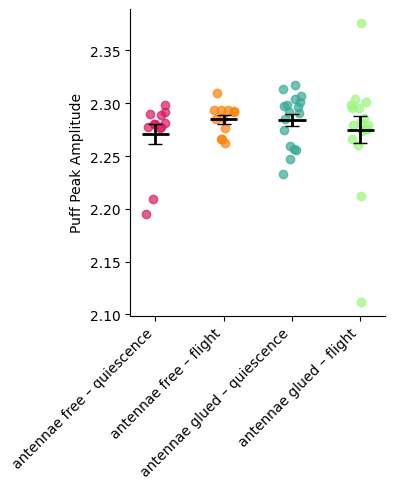

In [135]:
# 1. load CSV with per fly peuff peak data
puffPeak_perFly = pd.read_csv('/Users/nunno/Library/CloudStorage/OneDrive-Vanderbilt/revised_APN2publication_data/puffPeak_perFly.csv') 

def plot_per_fly_average_puff_peak(puff_df,labels,colors,figsize=(4, 5)):
    
    plt.figure(figsize=figsize)
    ax = plt.gca()

    # Plot individual flies + mean ± SEM
    for i, label in enumerate(labels):
        subset = puff_df.loc[puff_df['condition'] == label['date', 'expNumber', 'puff_peak_amplitude']].dropna(subset=['puff_peak_amplitude'])
        values = subset['puff_peak_amplitude']

        # Jitter individual flies
        x_jitter = (np.random.uniform(-0.15,0.15,size=len(values))+ i)

        ax.scatter(x_jitter,values,color=colors[i],alpha=0.7)

        # Mean ± SEM
        mean_val = np.nanmean(values)

        sem_val = (np.nanstd(values, ddof=1)/ np.sqrt(len(values)))

        # Mean line
        ax.hlines(mean_val,i - 0.2, i + 0.2, color='black', linewidth=2)

        # SEM
        ax.errorbar(i, mean_val, yerr=sem_val,fmt='none',ecolor='black',elinewidth=2,capsize=5)

    # Formatting
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Puff Peak Amplitude')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(top=False, right=False)
    
    plt.tight_layout()
    plt.show()

# Call function
per_fly_puff = plot_per_fly_average_puff_peak(puffPeak_perFly,labels,colors)


In [137]:
def test_puff_peak_amplitude(peak_df, labels):
    value_col = 'puff_peak_amplitude'

    # Define comparisons
    paired_comparisons = [('antennae free – quiescence','antennae free – flight'),
        ('antennae glued – quiescence','antennae glued – flight')]

    unpaired_comparisons = [('antennae free – quiescence','antennae glued – quiescence'),
        ('antennae free – flight', 'antennae glued – flight')]

    # average puffs within each fly
    fly_df = (peak_df.groupby(['date', 'expNumber', 'condition'], as_index=False)[value_col].mean())
    
    results = []

    # paired comparisons
    for cond1, cond2 in paired_comparisons:
        df1 = fly_df[fly_df['condition'] == cond1][['date', 'expNumber', value_col]].dropna()
        df2 = fly_df[fly_df['condition'] == cond2][['date', 'expNumber', value_col]].dropna()

        # Match the same fly
        paired = pd.merge(df1,df2,on=['date', 'expNumber'],suffixes=('_1', '_2'))
        vals1 = paired[f'{value_col}_1'].values
        vals2 = paired[f'{value_col}_2'].values

        print('\n' + '=' * 60)
        print(f'PAIRED: {cond1} vs {cond2}')
        print(f'n = {len(paired)} paired flies')

        if len(paired) < 3:
            print('Not enough paired observations for testing.')
            continue

        # Normality of paired differences
        differences = vals2 - vals1
        shapiro_stat, shapiro_p = shapiro(differences)

        print(f'Shapiro-Wilk normality test on differences: 'f'p = {shapiro_p:.4f}')

        # Choose test
        if shapiro_p > 0.05:
            stat, pval = ttest_rel(vals1,vals2)
            test_name = 'Paired t-test'
        else:
            stat, pval = wilcoxon(vals1,vals2)
            test_name = 'Wilcoxon signed-rank'

        print(f'Test: {test_name}')
        print(f'Statistic = {stat:.4f}, 'f'p = {pval:.4f}')

        results.append({'comparison': f'{cond1} vs {cond2}',
            'type': 'paired',
            'n': len(paired),
            'normality_p': shapiro_p,
            'test': test_name,
            'statistic': stat,
            'p_value': pval})

    # unpaired comparisons
    for cond1, cond2 in unpaired_comparisons:
        vals1 = fly_df.loc[fly_df['condition'] == cond1,value_col].dropna().values
        vals2 = fly_df.loc[fly_df['condition'] == cond2,value_col].dropna().values

        print('\n' + '=' * 60)
        print(f'UNPAIRED: {cond1} vs {cond2}')
        print(f'n1 = {len(vals1)}, n2 = {len(vals2)}')

        if len(vals1) < 3 or len(vals2) < 3:
            print('Not enough observations for testing.')
            continue

        # Normality of each group
        shapiro1_stat, shapiro1_p = shapiro(vals1)
        shapiro2_stat, shapiro2_p = shapiro(vals2)

        print(f'{cond1} Shapiro-Wilk: 'f'p = {shapiro1_p:.4f}')
        print(f'{cond2} Shapiro-Wilk: 'f'p = {shapiro2_p:.4f}')

        # Choose test
        if (shapiro1_p > 0.05 and shapiro2_p > 0.05):
            stat, pval = ttest_ind(vals1, vals2, equal_var=False)
            test_name = "Welch's t-test"
        else:
            stat, pval = mannwhitneyu(vals1, vals2, alternative='two-sided')
            test_name = 'Mann-Whitney U'

        print(f'Test: {test_name}')
        print(f'Statistic = {stat:.4f}, 'f'p = {pval:.4f}')

test_puff_peak_amplitude(peak_df=puffPeak_perFly,labels=labels)


PAIRED: antennae free – quiescence vs antennae free – flight
n = 12 paired flies
Shapiro-Wilk normality test on differences: p = 0.0257
Test: Wilcoxon signed-rank
Statistic = 15.0000, p = 0.0640

PAIRED: antennae glued – quiescence vs antennae glued – flight
n = 17 paired flies
Shapiro-Wilk normality test on differences: p = 0.0691
Test: Paired t-test
Statistic = 0.6314, p = 0.5367

UNPAIRED: antennae free – quiescence vs antennae glued – quiescence
n1 = 12, n2 = 17
antennae free – quiescence Shapiro-Wilk: p = 0.0004
antennae glued – quiescence Shapiro-Wilk: p = 0.1481
Test: Mann-Whitney U
Statistic = 70.0000, p = 0.1631

UNPAIRED: antennae free – flight vs antennae glued – flight
n1 = 12, n2 = 17
antennae free – flight Shapiro-Wilk: p = 0.2016
antennae glued – flight Shapiro-Wilk: p = 0.0008
Test: Mann-Whitney U
Statistic = 108.0000, p = 0.8076
